In [ ]:
import requests
import zipfile
import os

url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
zip_path = "taxi_zones.zip"

# Download
r = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(r.content)

print("Downloaded zip file")

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("taxi_zones")

print("Extracted shapefile")

Downloaded zip file
Extracted shapefile


In [ ]:
# ============================================================
# TASK 5 & 6 — MEMORY-SAFE VERSION FOR GOOGLE COLAB (12 GB)
# Strategy:
#   1. Load all 12 parquet files ONCE with only the columns we need
#   2. Build every small lookup table (zone×hour, zone×month, etc.)
#   3. Delete df_all immediately after
#   4. All subsequent work uses only small aggregated tables
# ============================================================

import pandas as pd
import numpy as np
import geopandas as gpd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ── STEP 1: Load raw trips — MINIMAL COLUMNS ONLY ─────────
# Only load what we actually need for Tasks 5 & 6
# This alone saves ~3 GB vs loading all columns

NEEDED_COLS = ["pickup_time", "PULocationID", "DOLocationID",
               "speed", "fare_amount"]

files = sorted(glob.glob("clean_*.parquet"))
print(f"Found {len(files)} monthly files")

parts = []
for f in files:
    chunk = pd.read_parquet(f, columns=NEEDED_COLS)
    chunk["pickup_time"] = pd.to_datetime(chunk["pickup_time"])
    chunk["hour"]        = chunk["pickup_time"].dt.hour
    chunk["month"]       = chunk["pickup_time"].dt.month
    parts.append(chunk)
    print(f"  loaded {f}  →  {len(chunk):,} rows")

df_all = pd.concat(parts, ignore_index=True)
del parts
print(f"\nTotal rows: {len(df_all):,}")
print(f"Columns: {df_all.columns.tolist()}")

Found 12 monthly files
  loaded clean_apr.parquet  →  3,134,688 rows
  loaded clean_aug.parquet  →  2,635,172 rows
  loaded clean_dec.parquet  →  3,226,246 rows
  loaded clean_feb.parquet  →  2,671,116 rows
  loaded clean_jan.parquet  →  2,643,232 rows
  loaded clean_jul.parquet  →  2,733,592 rows
  loaded clean_jun.parquet  →  3,152,290 rows
  loaded clean_mar.parquet  →  3,157,626 rows
  loaded clean_may.parquet  →  3,316,749 rows
  loaded clean_nov.parquet  →  3,230,258 rows
  loaded clean_oct.parquet  →  3,380,675 rows
  loaded clean_sep.parquet  →  3,192,659 rows

Total rows: 36,474,303
Columns: ['pickup_time', 'PULocationID', 'DOLocationID', 'speed', 'fare_amount', 'hour', 'month']


In [ ]:
# ── STEP 2: Build ALL small aggregates from df_all ────────
# Do this in one pass, then immediately delete df_all

# 2a. zone × hour  (for 5A and 6C radar source)
zone_hour_agg = (
    df_all.groupby(["PULocationID", "hour"])
    .size()
    .reset_index(name="trips")
)

# 2b. zone × month  (for 6C heatmap)
zone_month_agg = (
    df_all.groupby(["PULocationID", "month"])
    .size()
    .reset_index(name="trips")
)

# 2c. zone total pickup count
zone_total = (
    df_all.groupby("PULocationID")
    .size()
    .reset_index(name="trip_count")
    .rename(columns={"PULocationID": "LocationID"})
)

# 2d. zone total dropoff count
zone_dropoff = (
    df_all.groupby("DOLocationID")
    .size()
    .reset_index(name="dropoff_count")
    .rename(columns={"DOLocationID": "LocationID"})
)

# 2e. zone avg fare and speed  (needed for spatial feature table)
zone_stats = (
    df_all.groupby("PULocationID")
    .agg(avg_fare=("fare_amount", "mean"),
         avg_speed=("speed", "mean"))
    .reset_index()
    .rename(columns={"PULocationID": "LocationID"})
)

# ── FREE THE BIG DATAFRAME ────────────────────────────────
del df_all
import gc; gc.collect()
print("df_all deleted — RAM freed")
print(f"zone_hour_agg:   {zone_hour_agg.shape}")
print(f"zone_month_agg:  {zone_month_agg.shape}")
print(f"zone_total:      {zone_total.shape}")

df_all deleted — RAM freed
zone_hour_agg:   (5998, 3)
zone_month_agg:  (3057, 3)
zone_total:      (263, 2)


In [ ]:
# ── STEP 3: Load zone geometry + lookup ───────────────────
zones = pd.read_csv(
    "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
)[["LocationID", "Borough", "Zone"]]

gdf = gpd.read_file("taxi_zones/taxi_zones/taxi_zones.shp")[["LocationID", "geometry"]]
zone_info = (
    gdf.merge(zones, on="LocationID", how="left")
       .query("Borough not in ['Unknown', 'EWR']")
       .reset_index(drop=True)
)

id_to_name    = zones.set_index("LocationID")["Zone"].to_dict()
id_to_borough = zones.set_index("LocationID")["Borough"].to_dict()
print("Zone info loaded:", zone_info.shape)

Zone info loaded: (262, 4)


In [ ]:
# ── STEP 4: Rebuild zone_feat_proj (spatial feature table) ─
# Same as Task 1 — needed for DBSCAN, LISA, PCA

from sklearn.preprocessing import LabelEncoder
from libpysal.weights import Queen
import libpysal

zone_feat = (
    zone_info
    .merge(zone_stats,    on="LocationID", how="left")
    .merge(zone_total,    on="LocationID", how="left")
    .merge(zone_dropoff,  on="LocationID", how="left")
    .fillna(0)
)
zone_feat["net_flow"] = zone_feat["trip_count"] - zone_feat["dropoff_count"]

zone_feat = zone_feat.to_crs(epsg=4326)
zone_feat["centroid_lon"] = zone_feat.geometry.centroid.x
zone_feat["centroid_lat"] = zone_feat.geometry.centroid.y

zone_feat_proj = zone_feat.to_crs(epsg=32618).reset_index(drop=True)
zone_feat_proj["area_km2"] = zone_feat_proj.geometry.area / 1e6
zone_feat_proj["borough_enc"] = LabelEncoder().fit_transform(
    zone_feat_proj["Borough"].fillna("Unknown")
)

# Spatial weights + lag features
w = Queen.from_dataframe(zone_feat_proj, silence_warnings=True)
w.transform = "r"
zone_feat_proj["lag_trip_count"] = libpysal.weights.lag_spatial(w, zone_feat_proj["trip_count"])
zone_feat_proj["lag_avg_fare"]   = libpysal.weights.lag_spatial(w, zone_feat_proj["avg_fare"])
zone_feat_proj["lag_net_flow"]   = libpysal.weights.lag_spatial(w, zone_feat_proj["net_flow"])

print("zone_feat_proj ready:", zone_feat_proj.shape)

zone_feat_proj ready: (262, 16)


In [ ]:
# ── STEP 5: Rebuild DBSCAN clusters (from Task 3) ─────────
from sklearn.cluster import DBSCAN

dbscan_src = zone_feat_proj[zone_feat_proj["trip_count"] > 0].copy()
dbscan_src = dbscan_src.to_crs(epsg=4326)
dbscan_src["lon"] = dbscan_src.geometry.centroid.x
dbscan_src["lat"] = dbscan_src.geometry.centroid.y

coords  = dbscan_src[["lat", "lon"]].values
eps_rad = 1.5 / 6371.0
db = DBSCAN(eps=eps_rad, min_samples=3, algorithm="ball_tree", metric="haversine")
dbscan_src["cluster"] = db.fit_predict(np.radians(coords))

n_clusters = len(set(dbscan_src["cluster"])) - (1 if -1 in dbscan_src["cluster"].values else 0)
print(f"DBSCAN: {n_clusters} spatial clusters found")

# Cluster label = "C{id}: top zone name"
cluster_labels = {}
for cid in sorted(dbscan_src["cluster"].unique()):
    if cid == -1:
        continue
    top = (dbscan_src[dbscan_src["cluster"] == cid]
           .sort_values("trip_count", ascending=False).iloc[0]["Zone"])
    cluster_labels[cid] = f"C{cid}: {top}"

# loc → cluster mapping (small dict, no big df needed)
loc_to_cluster = dbscan_src.set_index("LocationID")["cluster"].to_dict()

DBSCAN: 10 spatial clusters found


In [ ]:
# ── STEP 6: Rebuild LISA labels (from Task 3) ─────────────
from esda.moran import Moran_Local

y_moran = zone_feat_proj["trip_count"].values
lisa    = Moran_Local(y_moran, w, seed=42)

sig   = lisa.p_sim < 0.05
quads = lisa.q
lisa_map = {1: "HH-HotSpot", 2: "LH", 3: "LL-ColdSpot", 4: "HL", 0: "Not-Sig"}
zone_feat_proj["lisa_q"]   = np.where(sig, quads, 0)
zone_feat_proj["lisa_lab"] = zone_feat_proj["lisa_q"].map(lisa_map)

loc_to_lisa = zone_feat_proj.set_index("LocationID")["lisa_lab"].to_dict()
print("LISA labels assigned")

LISA labels assigned


In [11]:
# ── STEP 7: Load hourly temporal series + states ──────────
# Already produced by Task 2/4 notebook — just load the cached file

hourly = pd.read_parquet("temporal_hourly_2024.parquet")
hourly.index = pd.to_datetime(hourly.index)
hourly.index.name = "pickup_hour"

# Recreate temporal states EXACTLY as in Task 4
demand_quantiles = hourly["trip_count"].quantile([0.33, 0.66]).to_numpy()
speed_quantiles  = hourly["mean_speed"].quantile([0.33, 0.66]).to_numpy()

hourly["demand_state"] = np.select(
    [hourly["trip_count"] < demand_quantiles[0],
     hourly["trip_count"] < demand_quantiles[1]],
    ["LOW_DEMAND", "MED_DEMAND"],
    default="HIGH_DEMAND"
)
hourly["speed_state"] = np.select(
    [hourly["mean_speed"] < speed_quantiles[0],
     hourly["mean_speed"] < speed_quantiles[1]],
    ["SLOW", "NORMAL_SPEED"],
    default="FAST"
)
hourly["state"] = hourly["demand_state"] + "|" + hourly["speed_state"]

# hour-of-day → most common state  (for mapping trips without reloading df_all)
hour_to_state = (
    hourly.groupby(hourly.index.hour)["state"]
    .agg(lambda s: s.value_counts().index[0])
    .to_dict()
)
print("Hourly temporal states ready")
print(hourly["state"].value_counts())

Hourly temporal states ready
state
LOW_DEMAND|FAST             2736
HIGH_DEMAND|SLOW            1852
MED_DEMAND|NORMAL_SPEED     1603
HIGH_DEMAND|NORMAL_SPEED    1132
MED_DEMAND|SLOW             1047
MED_DEMAND|FAST              247
LOW_DEMAND|NORMAL_SPEED      163
HIGH_DEMAND|FAST               4
Name: count, dtype: int64


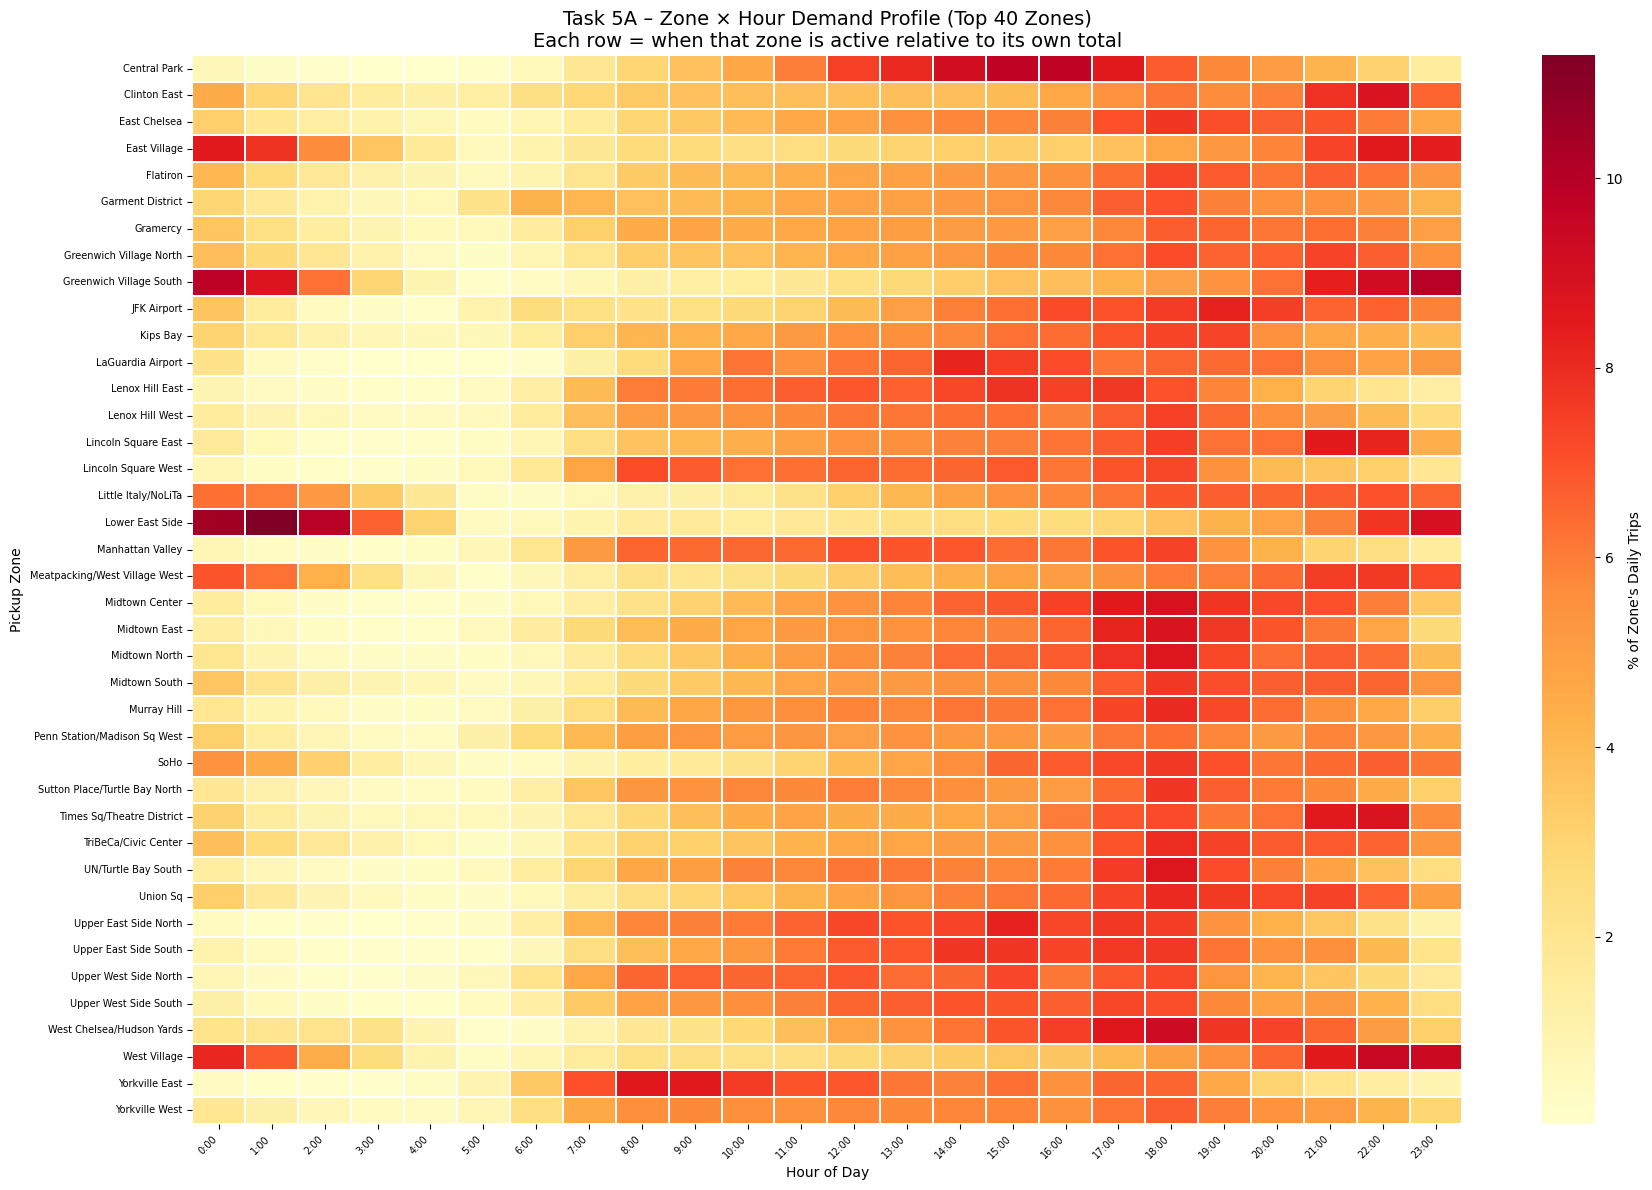

Saved task5A_zone_hour_heatmap.png


In [12]:
# ============================================================
# TASK 5A — Zone × Hour Demand Heatmap
# ============================================================

top40_ids = (
    zone_total.sort_values("trip_count", ascending=False)
    .head(40)["LocationID"].tolist()
)

zh = zone_hour_agg[zone_hour_agg["PULocationID"].isin(top40_ids)].copy()
zh_pivot = zh.pivot(index="PULocationID", columns="hour", values="trips").fillna(0)
zh_pivot.index = zh_pivot.index.map(id_to_name)

# Normalize each row → % of that zone's daily total
zh_norm = zh_pivot.div(zh_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(18, 12))
sns.heatmap(
    zh_norm, cmap="YlOrRd", linewidths=0.2, linecolor="white", ax=ax,
    cbar_kws={"label": "% of Zone's Daily Trips"}
)
ax.set_title(
    "Task 5A – Zone × Hour Demand Profile (Top 40 Zones)\n"
    "Each row = when that zone is active relative to its own total",
    fontsize=14
)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Pickup Zone")
plt.xticks(
    ticks=np.arange(24) + 0.5,
    labels=[f"{h}:00" for h in range(24)],
    rotation=45, ha="right", fontsize=7
)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig("task5A_zone_hour_heatmap.png", dpi=150)
plt.show()
print("Saved task5A_zone_hour_heatmap.png")

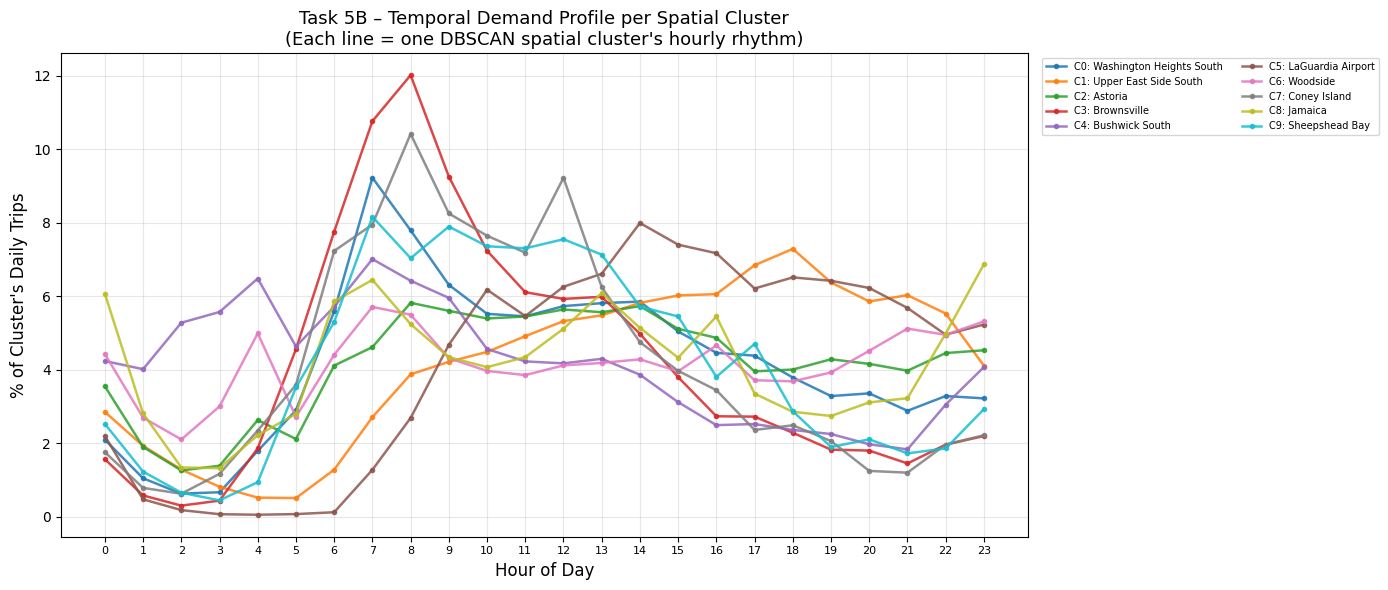

Saved task5B_cluster_temporal_profiles.png


In [14]:
# ============================================================
# TASK 5B — Temporal Profiles of Spatial Clusters
# ============================================================

# Map zone → cluster using loc_to_cluster dict (no big df needed)
zone_hour_agg["cluster"] = zone_hour_agg["PULocationID"].map(loc_to_cluster)
zh_clustered = zone_hour_agg.dropna(subset=["cluster"]).copy()
zh_clustered["cluster"] = zh_clustered["cluster"].astype(int)
zh_clustered = zh_clustered[zh_clustered["cluster"] >= 0]

cluster_hour = (
    zh_clustered.groupby(["cluster", "hour"])["trips"]
    .sum().reset_index()
)
cluster_hour_pivot = cluster_hour.pivot(
    index="cluster", columns="hour", values="trips"
).fillna(0)
cluster_hour_norm = cluster_hour_pivot.div(
    cluster_hour_pivot.sum(axis=1), axis=0
) * 100
cluster_hour_norm.index = cluster_hour_norm.index.map(cluster_labels)

fig, ax = plt.subplots(figsize=(14, 6))
cmap = plt.cm.get_cmap("tab10", len(cluster_hour_norm))

for i, (cname, row) in enumerate(cluster_hour_norm.iterrows()):
    ax.plot(range(24), row.values, marker="o", markersize=3,
            linewidth=1.8, label=cname, alpha=0.85, color=cmap(i))

ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("% of Cluster's Daily Trips", fontsize=12)
ax.set_title(
    "Task 5B – Temporal Demand Profile per Spatial Cluster\n"
    "(Each line = one DBSCAN spatial cluster's hourly rhythm)",
    fontsize=13
)
ax.set_xticks(range(24))
ax.set_xticklabels([str(h) for h in range(24)], fontsize=8)
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("task5B_cluster_temporal_profiles.png", dpi=150)
plt.show()
print("Saved task5B_cluster_temporal_profiles.png")

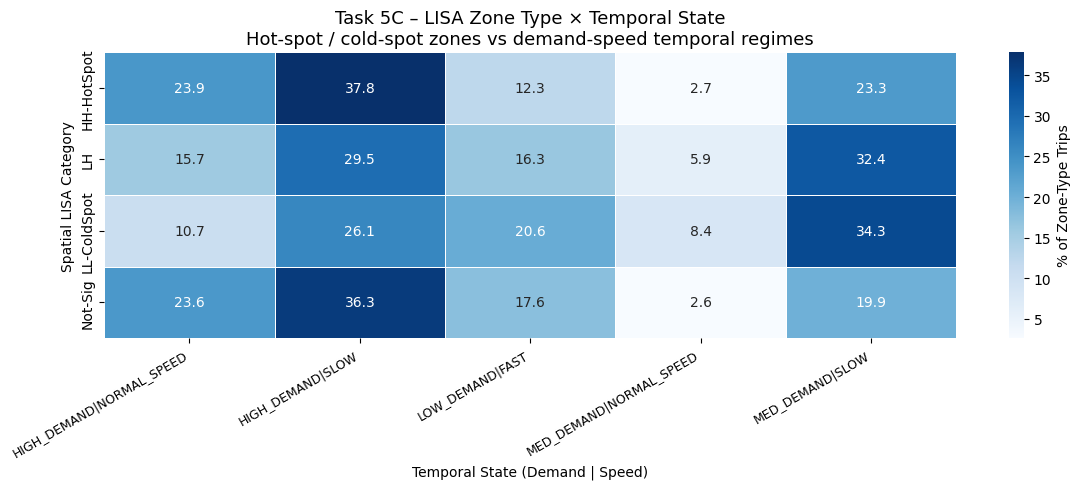


Dominant temporal state per LISA zone type:
lisa_lab
HH-HotSpot     HIGH_DEMAND|SLOW
LH              MED_DEMAND|SLOW
LL-ColdSpot     MED_DEMAND|SLOW
Not-Sig        HIGH_DEMAND|SLOW


In [15]:
# ============================================================
# TASK 5C — LISA Zone Type × Temporal State
# ============================================================

# Map zone → LISA label, then use zone_hour_agg to get trip volumes per hour
# Map hour → dominant temporal state using hour_to_state dict

zone_hour_agg["lisa_lab"]      = zone_hour_agg["PULocationID"].map(loc_to_lisa).fillna("Not-Sig")
zone_hour_agg["temporal_state"] = zone_hour_agg["hour"].map(hour_to_state)

lisa_state = (
    zone_hour_agg.groupby(["lisa_lab", "temporal_state"])["trips"]
    .sum().reset_index()
)
lisa_state_pivot = lisa_state.pivot(
    index="lisa_lab", columns="temporal_state", values="trips"
).fillna(0)
lisa_state_norm = lisa_state_pivot.div(lisa_state_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    lisa_state_norm, cmap="Blues", annot=True, fmt=".1f",
    linewidths=0.4, ax=ax,
    cbar_kws={"label": "% of Zone-Type Trips"}
)
ax.set_title(
    "Task 5C – LISA Zone Type × Temporal State\n"
    "Hot-spot / cold-spot zones vs demand-speed temporal regimes",
    fontsize=13
)
ax.set_xlabel("Temporal State (Demand | Speed)")
ax.set_ylabel("Spatial LISA Category")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("task5C_lisa_x_temporal_state.png", dpi=150)
plt.show()

print("\nDominant temporal state per LISA zone type:")
print(lisa_state_norm.idxmax(axis=1).to_string())

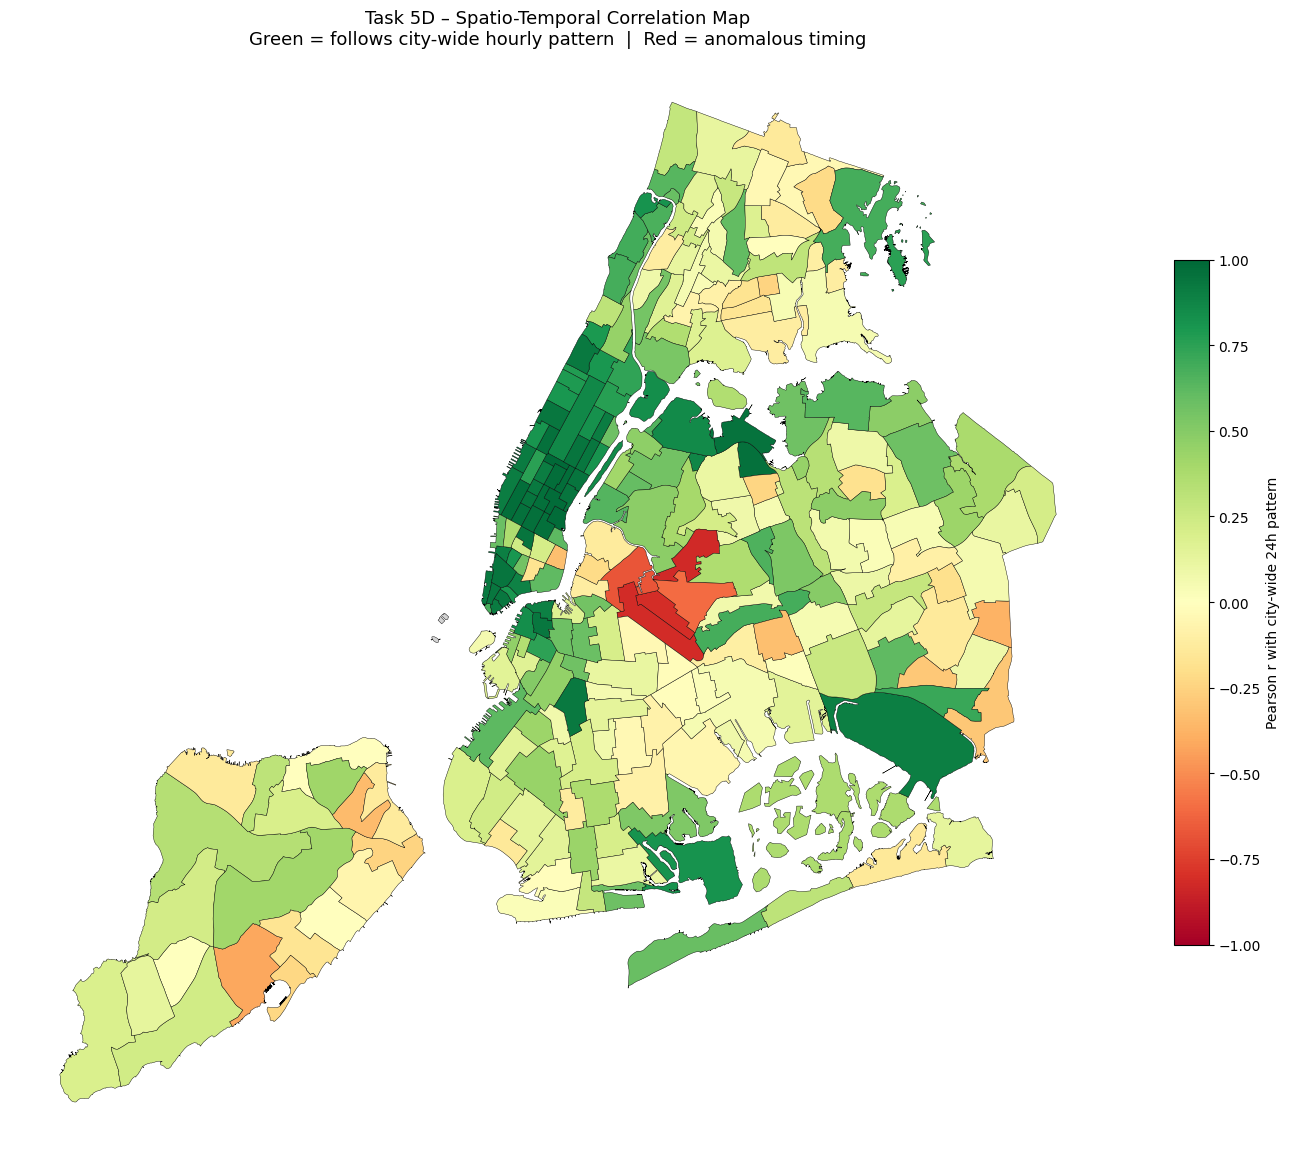


Most city-representative zones:
          Zone   Borough  temporal_corr
 Midtown North Manhattan       0.984943
   Murray Hill Manhattan       0.980411
      Kips Bay Manhattan       0.977386
  East Chelsea Manhattan       0.974620
Midtown Center Manhattan       0.974402
  Midtown East Manhattan       0.969012
      Gramercy Manhattan       0.967358
 Midtown South Manhattan       0.963250

Most anomalous zones:
               Zone       Borough  temporal_corr
            Maspeth        Queens      -0.822973
     Bushwick South      Brooklyn      -0.818550
     Bushwick North      Brooklyn      -0.806931
  East Williamsburg      Brooklyn      -0.678184
          Ridgewood        Queens      -0.608130
        Great Kills Staten Island      -0.420370
    Cambria Heights        Queens      -0.380042
Grymes Hill/Clifton Staten Island      -0.349918


In [16]:
# ============================================================
# TASK 5D — Spatio-Temporal Correlation Map
# ============================================================
# For each zone: correlate its 24h demand profile with city-wide 24h profile
# No big df needed — use zone_hour_agg (already built)

# City-wide 24h profile (% per hour)
global_24h = (
    zone_hour_agg.groupby("hour")["trips"].sum()
)
global_24h = global_24h / global_24h.sum()

# Per-zone 24h profile (normalized)
zone_24h_pivot = zone_hour_agg.pivot_table(
    index="PULocationID", columns="hour", values="trips", aggfunc="sum"
).fillna(0)
zone_24h_norm = zone_24h_pivot.div(zone_24h_pivot.sum(axis=1), axis=0)

# Pearson correlation of each zone with city-wide pattern
zone_corr = zone_24h_norm.apply(
    lambda row: row.corr(global_24h), axis=1
).reset_index()
zone_corr.columns = ["LocationID", "temporal_corr"]

zone_corr_geo = zone_info.merge(zone_corr, on="LocationID", how="left")
zone_corr_proj = zone_corr_geo.to_crs(epsg=32618)

fig, ax = plt.subplots(figsize=(14, 14))
zone_corr_proj.plot(
    column="temporal_corr",
    cmap="RdYlGn", vmin=-1, vmax=1,
    legend=True, edgecolor="black", linewidth=0.3, ax=ax,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"label": "Pearson r with city-wide 24h pattern",
                 "shrink": 0.5}
)
ax.set_title(
    "Task 5D – Spatio-Temporal Correlation Map\n"
    "Green = follows city-wide hourly pattern  |  Red = anomalous timing",
    fontsize=13
)
ax.axis("off")
plt.tight_layout()
plt.savefig("task5D_spatiotemporal_corr_map.png", dpi=150)
plt.show()

zone_corr_named = zone_corr_proj[["Zone","Borough","temporal_corr"]].dropna()
print("\nMost city-representative zones:")
print(zone_corr_named.sort_values("temporal_corr", ascending=False).head(8).to_string(index=False))
print("\nMost anomalous zones:")
print(zone_corr_named.sort_values("temporal_corr").head(8).to_string(index=False))

In [17]:
# ============================================================
# TASK 5E — Joint Inference Summary Table
# ============================================================

# Peak hour per zone (from zone_hour_agg — small table)
zone_peak_hour = (
    zone_hour_agg.sort_values("trips", ascending=False)
    .drop_duplicates(subset="PULocationID")
    [["PULocationID", "hour"]]
    .rename(columns={"PULocationID": "LocationID", "hour": "peak_hour"})
)

# Dominant temporal state per zone (map peak hour → state)
zone_peak_hour["dominant_state"] = zone_peak_hour["peak_hour"].map(hour_to_state)

# Build joint summary
summary = (
    zone_feat_proj[["LocationID", "Zone", "Borough", "trip_count"]]
    .merge(
        dbscan_src[["LocationID", "cluster"]].assign(
            cluster_label=dbscan_src["cluster"].map(
                lambda x: cluster_labels.get(x, "Noise")
            )
        ),
        on="LocationID", how="left"
    )
    .merge(zone_peak_hour, on="LocationID", how="left")
    .merge(
        zone_feat_proj[["LocationID", "lisa_lab"]],
        on="LocationID", how="left"
    )
)

summary = (
    summary[summary["trip_count"] > 500]
    .sort_values("trip_count", ascending=False)
)

print("=" * 80)
print("JOINT SPATIO-TEMPORAL INFERENCE — Top 30 Zones")
print("=" * 80)
print(
    summary[["Zone","Borough","cluster_label","lisa_lab",
             "peak_hour","dominant_state","trip_count"]]
    .head(30)
    .to_string(index=False)
)

JOINT SPATIO-TEMPORAL INFERENCE — Top 30 Zones
                         Zone   Borough             cluster_label   lisa_lab  peak_hour           dominant_state  trip_count
        Upper East Side South Manhattan C1: Upper East Side South HH-HotSpot       15.0         HIGH_DEMAND|SLOW   1767533.0
               Midtown Center Manhattan C1: Upper East Side South HH-HotSpot       18.0         HIGH_DEMAND|SLOW   1746637.0
        Upper East Side North Manhattan C1: Upper East Side South HH-HotSpot       15.0         HIGH_DEMAND|SLOW   1598696.0
                 Midtown East Manhattan C1: Upper East Side South HH-HotSpot       18.0         HIGH_DEMAND|SLOW   1291753.0
    Times Sq/Theatre District Manhattan C1: Upper East Side South HH-HotSpot       22.0 HIGH_DEMAND|NORMAL_SPEED   1230154.0
 Penn Station/Madison Sq West Manhattan C1: Upper East Side South HH-HotSpot       18.0         HIGH_DEMAND|SLOW   1223296.0
          Lincoln Square East Manhattan C1: Upper East Side South HH-HotSpot  

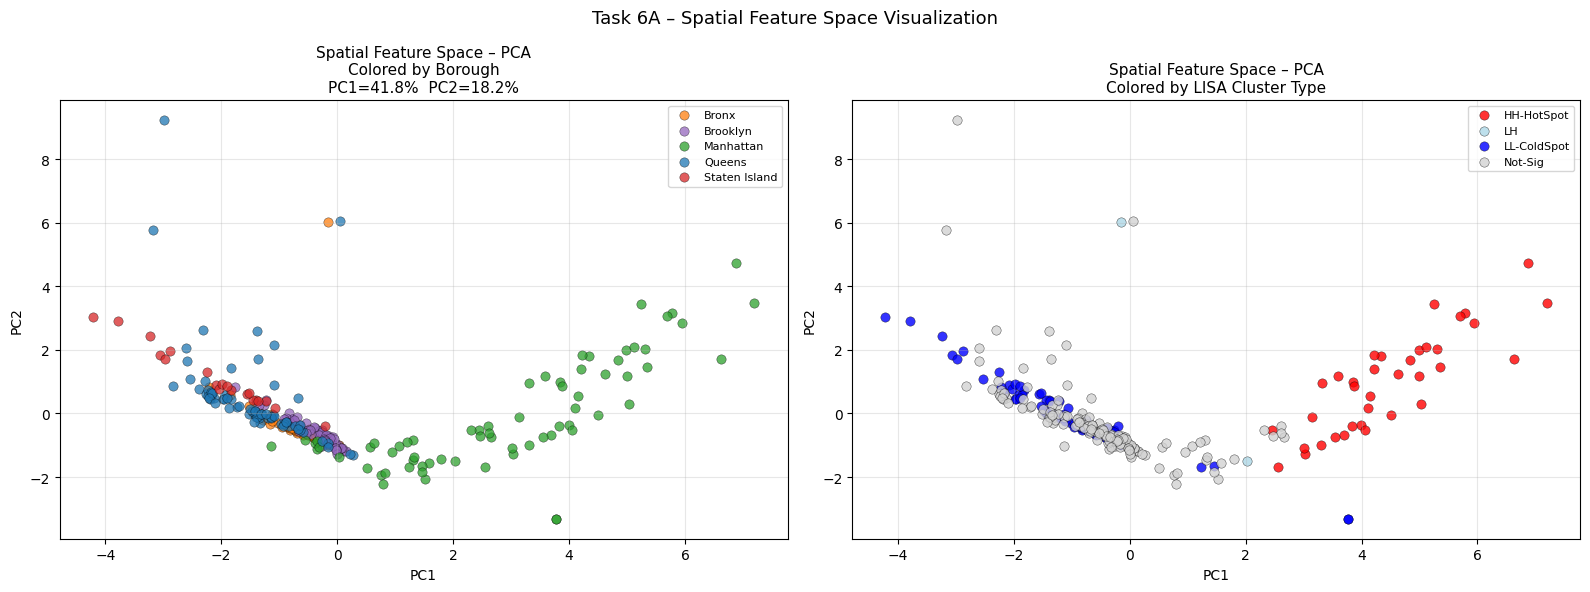

Variance explained by PC1, PC2: [0.418 0.182]


In [18]:
# ============================================================
# TASK 6A — Spatial Feature Space PCA
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols_sp = [
    "avg_fare", "avg_speed", "trip_count", "dropoff_count",
    "net_flow", "centroid_lat", "centroid_lon",
    "area_km2", "lag_trip_count", "lag_avg_fare", "lag_net_flow"
]

df_pca = zone_feat_proj[feature_cols_sp + ["Borough", "lisa_lab"]].dropna(
    subset=feature_cols_sp
).copy()

X_sp = StandardScaler().fit_transform(df_pca[feature_cols_sp])
pca  = PCA(n_components=2, random_state=42)
pcs  = pca.fit_transform(X_sp)
df_pca["PC1"] = pcs[:, 0]
df_pca["PC2"] = pcs[:, 1]

borough_palette = dict(zip(
    df_pca["Borough"].unique(),
    plt.cm.tab10.colors[:df_pca["Borough"].nunique()]
))
lisa_palette = {
    "HH-HotSpot": "red", "HL": "pink",
    "LH": "lightblue", "LL-ColdSpot": "blue", "Not-Sig": "lightgrey"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for b, grp in df_pca.groupby("Borough"):
    axes[0].scatter(grp["PC1"], grp["PC2"],
                    c=[borough_palette[b]], label=b,
                    alpha=0.75, s=45, edgecolors="k", linewidths=0.3)
axes[0].set_title(
    f"Spatial Feature Space – PCA\nColored by Borough\n"
    f"PC1={pca.explained_variance_ratio_[0]*100:.1f}%  "
    f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%",
    fontsize=11
)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

for ll, grp in df_pca.groupby("lisa_lab"):
    axes[1].scatter(grp["PC1"], grp["PC2"],
                    c=lisa_palette.get(ll, "grey"), label=ll,
                    alpha=0.8, s=45, edgecolors="k", linewidths=0.3)
axes[1].set_title("Spatial Feature Space – PCA\nColored by LISA Cluster Type", fontsize=11)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle("Task 6A – Spatial Feature Space Visualization", fontsize=13)
plt.tight_layout()
plt.savefig("task6A_spatial_pca.png", dpi=150)
plt.show()

print("Variance explained by PC1, PC2:", pca.explained_variance_ratio_.round(3))

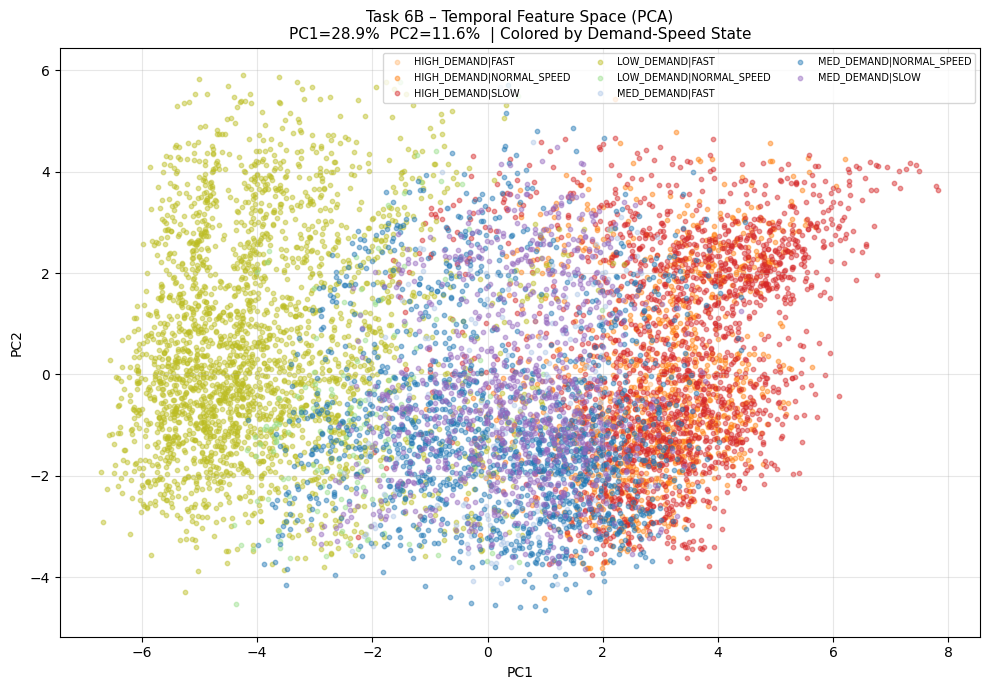

In [19]:
# ============================================================
# TASK 6B — Temporal Feature Space PCA
# ============================================================

def make_supervised(df):
    f = df.copy()
    f["hour"]          = f.index.hour
    f["day_of_week"]   = f.index.dayofweek
    f["month"]         = f.index.month
    f["day_of_year"]   = f.index.dayofyear
    f["is_weekend"]    = (f["day_of_week"] >= 5).astype(int)
    f["is_peak"]       = f["hour"].isin([7,8,9,16,17,18,19]).astype(int)
    f["is_late_night"] = f["hour"].isin([0,1,2,3,4]).astype(int)
    for period, col in [(24,"hour"),(7,"day_of_week"),(12,"month"),(366,"day_of_year")]:
        f[f"{col}_sin"] = np.sin(2*np.pi*f[col]/period)
        f[f"{col}_cos"] = np.cos(2*np.pi*f[col]/period)
    for lag in [1, 2, 3, 24, 48, 72, 168]:
        f[f"lag_{lag}"] = f["trip_count"].shift(lag)
    for window in [3, 6, 24, 168]:
        s = f["trip_count"].shift(1)
        f[f"roll_mean_{window}"] = s.rolling(window).mean()
        f[f"roll_std_{window}"]  = s.rolling(window).std()
    return f.dropna()

sup       = make_supervised(hourly)
feat_cols_t = [c for c in sup.columns
               if c not in ("trip_count","demand_state","speed_state","state")]

X_t   = StandardScaler().fit_transform(sup[feat_cols_t])
pca_t = PCA(n_components=2, random_state=42)
pcs_t = pca_t.fit_transform(X_t)
sup["TPC1"] = pcs_t[:, 0]
sup["TPC2"] = pcs_t[:, 1]

state_colors = {
    "HIGH_DEMAND|SLOW":         "#d62728",
    "HIGH_DEMAND|NORMAL_SPEED": "#ff7f0e",
    "HIGH_DEMAND|FAST":         "#ffbb78",
    "MED_DEMAND|SLOW":          "#9467bd",
    "MED_DEMAND|NORMAL_SPEED":  "#1f77b4",
    "MED_DEMAND|FAST":          "#aec7e8",
    "LOW_DEMAND|SLOW":          "#2ca02c",
    "LOW_DEMAND|NORMAL_SPEED":  "#98df8a",
    "LOW_DEMAND|FAST":          "#bcbd22",
}

fig, ax = plt.subplots(figsize=(10, 7))
for state, grp in sup.groupby("state"):
    ax.scatter(grp["TPC1"], grp["TPC2"],
               c=state_colors.get(state, "grey"),
               label=state, alpha=0.45, s=10)

ax.set_title(
    f"Task 6B – Temporal Feature Space (PCA)\n"
    f"PC1={pca_t.explained_variance_ratio_[0]*100:.1f}%  "
    f"PC2={pca_t.explained_variance_ratio_[1]*100:.1f}%  "
    f"| Colored by Demand-Speed State",
    fontsize=11
)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=7, ncol=3, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("task6B_temporal_pca.png", dpi=150)
plt.show()

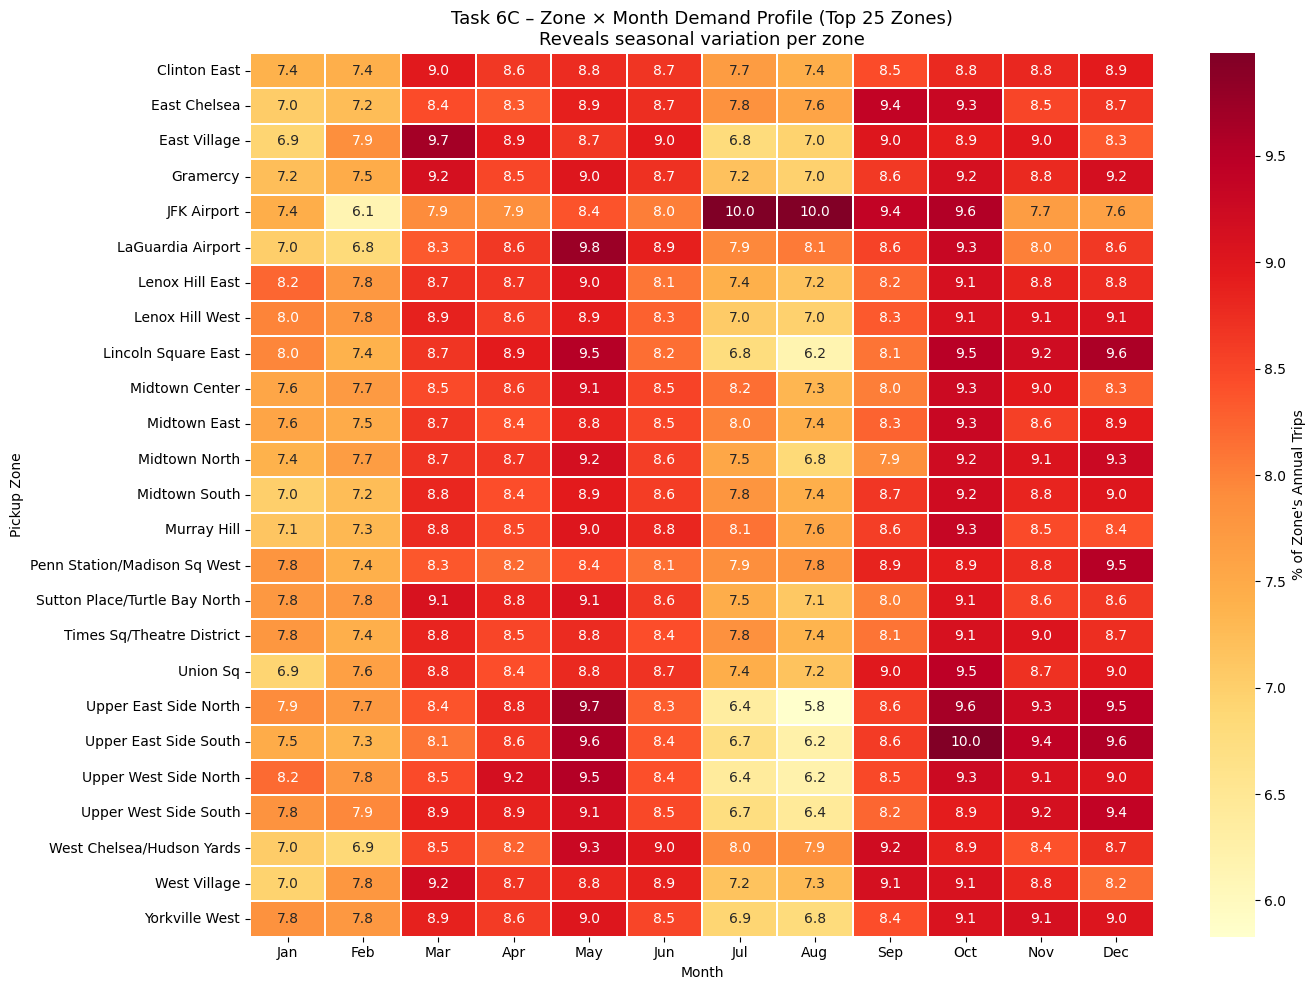

In [20]:
# ============================================================
# TASK 6C — Zone × Month Demand Heatmap
# ============================================================

top25_ids = (
    zone_total.sort_values("trip_count", ascending=False)
    .head(25)["LocationID"].tolist()
)

zm = zone_month_agg[zone_month_agg["PULocationID"].isin(top25_ids)].copy()
zm_pivot = zm.pivot(index="PULocationID", columns="month", values="trips").fillna(0)
zm_pivot.index   = zm_pivot.index.map(id_to_name)
zm_pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]

zm_norm = zm_pivot.div(zm_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    zm_norm, cmap="YlOrRd", annot=True, fmt=".1f",
    linewidths=0.3, linecolor="white", ax=ax,
    cbar_kws={"label": "% of Zone's Annual Trips"}
)
ax.set_title(
    "Task 6C – Zone × Month Demand Profile (Top 25 Zones)\n"
    "Reveals seasonal variation per zone",
    fontsize=13
)
ax.set_xlabel("Month"); ax.set_ylabel("Pickup Zone")
plt.tight_layout()
plt.savefig("task6C_zone_month_heatmap.png", dpi=150)
plt.show()

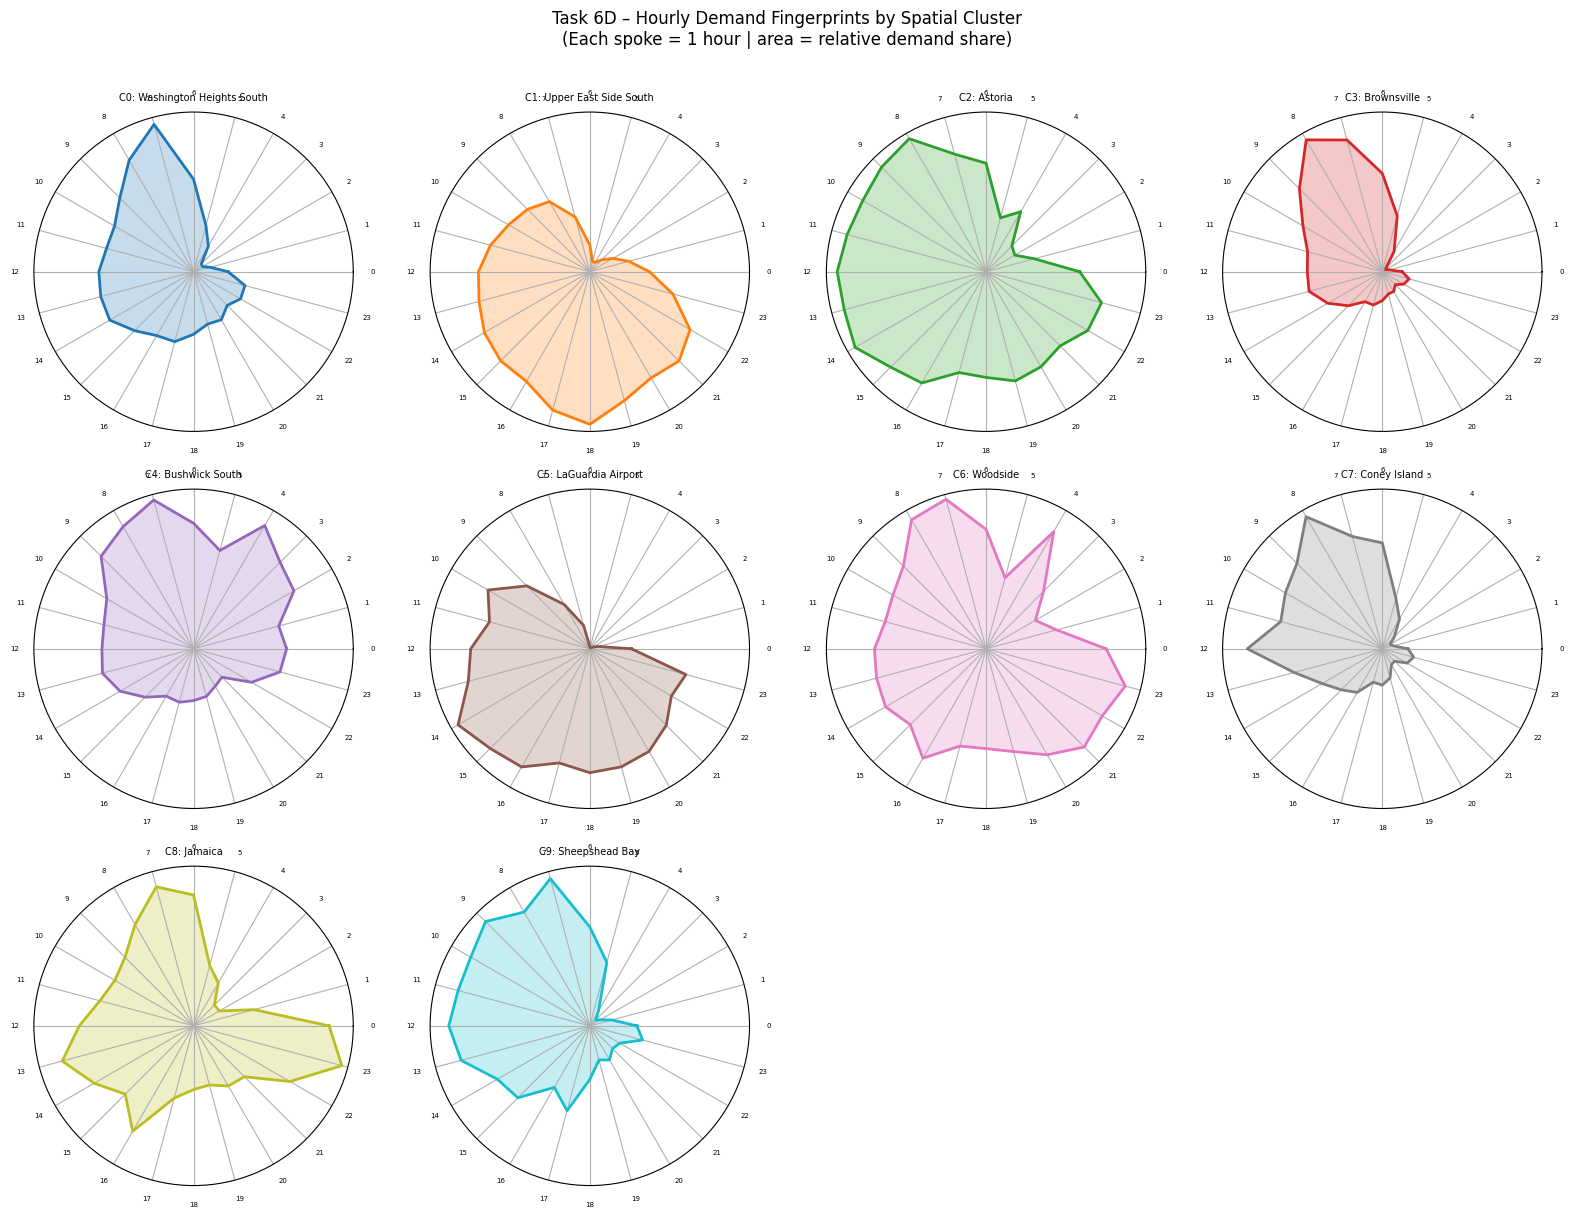

In [21]:
# ============================================================
# TASK 6D — Radar Charts: Cluster Temporal Fingerprints
# ============================================================

hours  = list(range(24))
angles = np.linspace(0, 2 * np.pi, 24, endpoint=False).tolist()
angles_closed = angles + angles[:1]

n_real = len(cluster_hour_norm)
ncols  = min(4, n_real)
nrows  = int(np.ceil(n_real / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 4 * nrows),
    subplot_kw=dict(polar=True)
)
axes = np.array(axes).flatten()
cmap_r = plt.cm.get_cmap("tab10", n_real)

for i, (cname, row) in enumerate(cluster_hour_norm.iterrows()):
    vals = row.values.tolist() + [row.values[0]]
    ax   = axes[i]
    ax.plot(angles_closed, vals, color=cmap_r(i), linewidth=2)
    ax.fill(angles_closed, vals, color=cmap_r(i), alpha=0.25)
    ax.set_xticks(angles)
    ax.set_xticklabels([str(h) for h in hours], fontsize=5)
    ax.set_title(cname, size=7, pad=8)
    ax.yaxis.set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Task 6D – Hourly Demand Fingerprints by Spatial Cluster\n"
    "(Each spoke = 1 hour | area = relative demand share)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("task6D_cluster_radar.png", dpi=150)
plt.show()

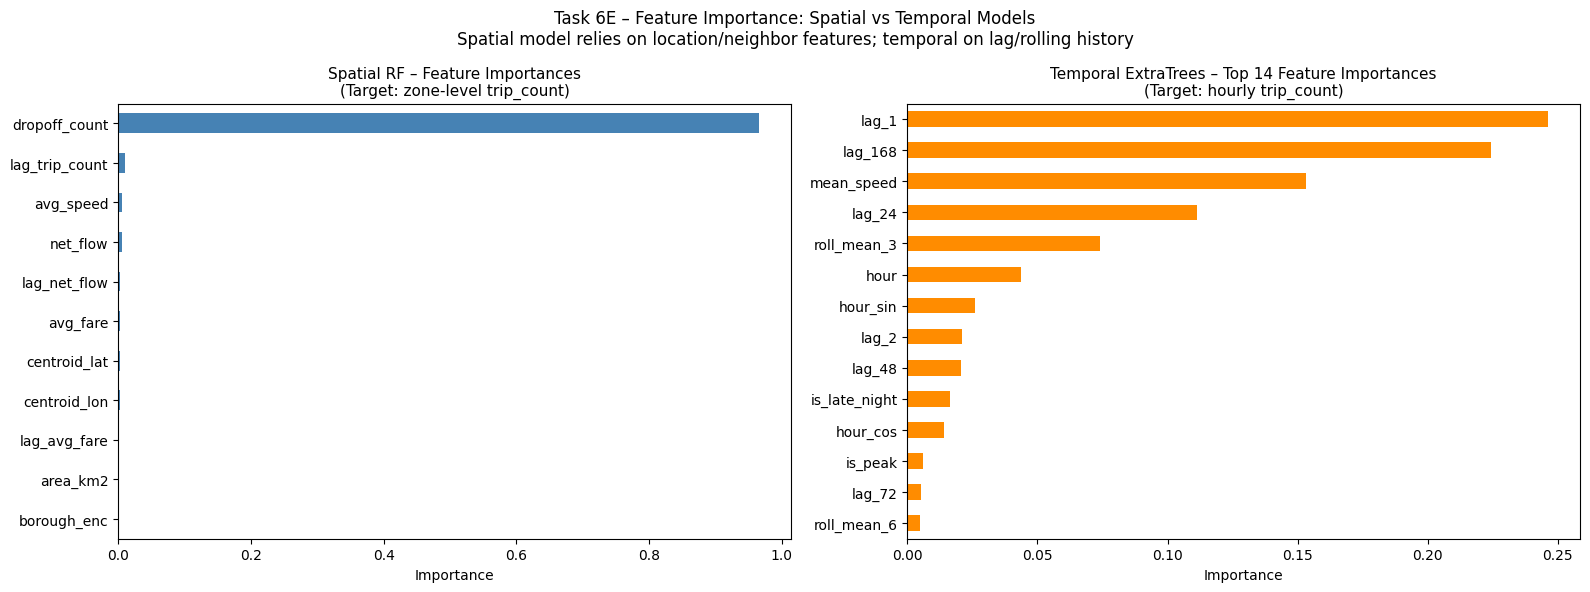

In [22]:
# ============================================================
# TASK 6E — Feature Importance Comparison (Spatial vs Temporal)
# ============================================================

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# --- Spatial RF (lightweight — small zone table, ~200 rows) ---
feat_sp = [
    "avg_fare", "avg_speed", "dropoff_count", "net_flow",
    "centroid_lat", "centroid_lon", "area_km2", "borough_enc",
    "lag_trip_count", "lag_avg_fare", "lag_net_flow"
]
df_ml = zone_feat_proj[zone_feat_proj["trip_count"] > 0].dropna(
    subset=feat_sp + ["trip_count"]
)
X_sp_ml = df_ml[feat_sp].values
y_sp_ml = np.log1p(df_ml["trip_count"].values)

rf_sp = RandomForestRegressor(
    n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
)
rf_sp.fit(X_sp_ml, y_sp_ml)
sp_imp = pd.Series(rf_sp.feature_importances_, index=feat_sp).sort_values()

# --- Temporal ExtraTrees (small — 8784 rows) ---
sup_train = sup[sup.index < "2024-12-01"]
et = ExtraTreesRegressor(
    n_estimators=100, min_samples_leaf=2,
    max_features=0.85, n_jobs=-1, random_state=42
)
et.fit(sup_train[feat_cols_t], sup_train["trip_count"])
t_imp = (
    pd.Series(et.feature_importances_, index=feat_cols_t)
    .sort_values(ascending=False).head(14)
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sp_imp.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title(
    "Spatial RF – Feature Importances\n(Target: zone-level trip_count)",
    fontsize=11
)
axes[0].set_xlabel("Importance")

t_imp.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title(
    "Temporal ExtraTrees – Top 14 Feature Importances\n(Target: hourly trip_count)",
    fontsize=11
)
axes[1].set_xlabel("Importance")

plt.suptitle(
    "Task 6E – Feature Importance: Spatial vs Temporal Models\n"
    "Spatial model relies on location/neighbor features; temporal on lag/rolling history",
    fontsize=12
)
plt.tight_layout()
plt.savefig("task6E_feature_importance_comparison.png", dpi=150)
plt.show()